In [16]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "DataSet" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from scipy import stats as sps
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedShuffleSplit, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, _tree, plot_tree
from xgboost import XGBClassifier, XGBRegressor


PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


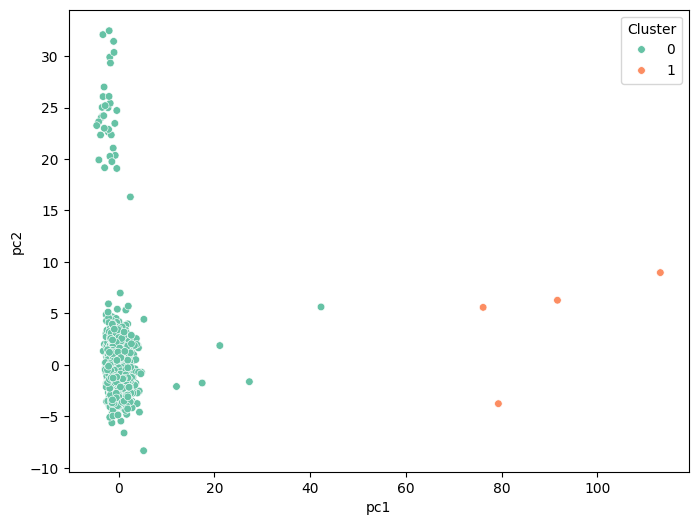

In [17]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, 132)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['Cluster'] = labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='Cluster', s=30, palette='Set2')
plt.show()

---
---

依照KMEANS分的cluster=0/1各群做local的近似函數, 只是格子點太大, 現在在想方設法讓模型有個結果

全下

In [19]:
# ====== 最低限度修改：降峰值記憶體拷貝 + 取消 X1 hstack ======
# local_surrogate_block_fullgrid_ols：
# - 大矩陣用 float32（Zs/Z/y/X_block），累積量用 float64
# - 不建立 X1 = [1, X_block]，改手動更新 Sxx/Sxy
# - np.repeat 改成預先配置 + 填值（少一次不必要拷貝路徑）
def _center_index(q, k):
    # all-zero offset 對應 base-(2k+1) 數字每位都是 k
    B = 2 * k + 1
    return int(k * (B**q - 1) // (B - 1)) if B != 1 else 0

def _iter_fullgrid_offsets_chunked(q, k, chunk_size, center_first=True):
    """
    以 chunk 方式產生 full grid offsets，不一次存滿 (2k+1)^q × q。
    若 center_first=True，先 yield 全 0 offset，再 yield 其餘點（不重複）。
    """
    B = 2 * k + 1
    n = int(B**q)

    if center_first:
        cidx = _center_index(q, k)
        yield np.zeros((1, q), dtype=float), np.array([cidx], dtype=np.int64), n

        # 0..n-1 排除 cidx
        s = 0
        while s < n:
            e = min(n, s + chunk_size)
            idx = np.arange(s, e, dtype=np.int64)
            mask = idx != cidx
            if mask.any():
                idx2 = idx[mask]
                yield _offsets_from_linear_indices(idx2, q, k), idx2, n
            s = e
    else:
        s = 0
        while s < n:
            e = min(n, s + chunk_size)
            idx = np.arange(s, e, dtype=np.int64)
            yield _offsets_from_linear_indices(idx, q, k), idx, n
            s = e

def _offsets_from_linear_indices(idx, q, k):
    """
    idx: (m,) 線性索引
    回傳 offsets: (m, q)，每列是 [-k..k] 的 q 維整數位移（float32）
    """
    idx = idx.astype(np.int64, copy=False)
    B = 2 * k + 1
    offsets = np.empty((idx.size, q), dtype=np.float32)
    x = idx.copy()
    for d in range(q - 1, -1, -1):
        x, r = np.divmod(x, B)
        offsets[:, d] = (r.astype(np.float32) - np.float32(k))
    return offsets


def _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n, q):
    """
    用累積量求 OLS 係數與統計量
    Sxx = X'X (q+1,q+1), Sxy = X'y (q+1,), Syy = y'y, sum_y = sum(y)
    """
    p_params = q + 1
    df_resid = n - p_params
    out = {}

    # beta
    try:
        beta = np.linalg.solve(Sxx, Sxy)
    except np.linalg.LinAlgError:
        beta = np.full(p_params, np.nan, dtype=np.float64)

    # SSE = y'y - 2 b'X'y + b'X'X b
    if np.all(np.isfinite(beta)):
        SSE = float(Syy - 2.0 * beta @ Sxy + beta @ (Sxx @ beta))
    else:
        SSE = np.nan

    # TSS
    ybar = float(sum_y / n) if n > 0 else np.nan
    TSS = float(Syy - n * (ybar**2)) if n > 0 else np.nan

    # sigma2
    sigma2 = float(SSE / df_resid) if (df_resid > 0 and np.isfinite(SSE)) else np.nan

    # inv(X'X)
    try:
        Sxx_inv = np.linalg.inv(Sxx)
    except np.linalg.LinAlgError:
        Sxx_inv = np.full_like(Sxx, np.nan, dtype=np.float64)

    # se, t, p
    if np.isfinite(sigma2) and np.all(np.isfinite(Sxx_inv)):
        cov = sigma2 * Sxx_inv
        se = np.sqrt(np.diag(cov))
        tval = beta / se
        if df_resid > 0:
            pval = 2.0 * sps.t.sf(np.abs(tval), df=df_resid)
        else:
            pval = np.full_like(tval, np.nan, dtype=np.float64)
    else:
        se = np.full(p_params, np.nan, dtype=np.float64)
        tval = np.full(p_params, np.nan, dtype=np.float64)
        pval = np.full(p_params, np.nan, dtype=np.float64)

    # r2
    r2 = (1.0 - SSE / TSS) if (np.isfinite(SSE) and np.isfinite(TSS) and TSS > 0) else np.nan

    # aic/bic
    kparam = p_params
    if n > 0 and np.isfinite(SSE) and SSE > 0:
        ll_term = n * np.log(SSE / n)
        aic = float(ll_term + 2.0 * kparam)
        bic = float(ll_term + np.log(n) * kparam)
    else:
        aic = np.nan
        bic = np.nan

    out["beta"] = beta
    out["SSE"] = SSE
    out["r2"] = float(r2) if np.isfinite(r2) else np.nan
    out["se"] = se                   
    out["t"] = tval
    out["p"] = pval
    out["aic"] = aic
    out["bic"] = bic
    out["df_resid"] = int(df_resid)
    return out


def local_surrogate_block_fullgrid_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    chunk_size=10000,
    store_yhat=False,
    store_yblackbox=False,
):
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    # scaler.transform 通常吐 float64；立刻壓回 float32（大矩陣都用 float32）
    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")

    B = 2 * k + 1
    n_total = int(B**q)

    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    # sufficient stats（用 float64 累積）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)
    Syy = 0.0
    sum_y = 0.0
    n_seen = 0

    # 預先配置 chunk 用的大矩陣（重複利用，避免每回合配置/釋放）
    Zs_chunk = np.empty((chunk_size, p_model), dtype=np.float32)

    for offsets_q, idx_linear, n_full in _iter_fullgrid_offsets_chunked(q, k, chunk_size, center_first=True):
        m = offsets_q.shape[0]
        if m == 0:
            continue

        # X_block: (m,q) 只用 float32
        X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

        # 生成完整 p 維輸入（scaled 空間）
        # 原本 np.repeat 會走一條明顯的拷貝路徑；改成填值到預配置陣列
        Zs = Zs_chunk[:m]
        Zs[:] = x0_scaled  # broadcast fill
        Zs[:, block_cols] += X_block

        # 回到原始尺度再進黑箱（仍盡量保持 float32）
        if scaler is not None:
            Z_chunk = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
        else:
            Z_chunk = Zs

        if hasattr(blackbox_model, "predict_proba"):
            y = blackbox_model.predict_proba(Z_chunk)[:, 1]
        else:
            y = blackbox_model.predict(Z_chunk)

        y = np.asarray(y, dtype=np.float32).reshape(-1)
        if y.size != m:
            raise ValueError("blackbox 輸出長度與 chunk 不一致")

        # ====== 不建立 X1=[1, X_block]，改手動更新（等價但少一次 hstack） ======
        # Sxx = [[m,      1'X],
        #        [X'1,    X'X]]
        Sxx[0, 0] += m
        sx = X_block.sum(axis=0, dtype=np.float64)          # (q,)
        Sxx[0, 1:] += sx
        Sxx[1:, 0] += sx
        Sxx[1:, 1:] += (X_block.T @ X_block).astype(np.float64, copy=False)

        # Sxy = [1'y, X'y]
        sy = float(y.sum(dtype=np.float64))
        Sxy[0] += sy
        Sxy[1:] += (X_block.T @ y).astype(np.float64, copy=False)

        # Syy, sum_y
        Syy += float(y @ y)
        sum_y += sy
        n_seen += int(m)

    if n_seen != n_total:
        raise RuntimeError(f"n_seen({n_seen}) != n_total({n_total})")

    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n_seen, q)

    info = {
        "n": int(n_seen),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),              
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
    }
    return info


def run_blockwise_fullgrid_pvalues(
    x0,
    blackbox_model,
    feature_names,
    block_size,
    k,
    delta=0.1,
    scaler=None,
    chunk_size=10000,
):
    p = len(feature_names)
    rows = []

    n_blocks = int(np.ceil(p / block_size))
    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)
        block_cols = list(range(j0, j1))

        info = local_surrogate_block_fullgrid_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=block_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            chunk_size=chunk_size,
            store_yhat=False,
            store_yblackbox=False,
        )

        for t, col in enumerate(block_cols):
            coef = float(info["coef_block"][t])
            rows.append({
                "feature": feature_names[col],
                "block_id": int(bi),
                "coef": coef,
                "abs_coef": abs(coef),                
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_block": info["r2"],
                "df_resid": info["df_resid"],
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
    df["rank_p"] = np.arange(1, len(df) + 1)
    return df

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]
# 只改「呼叫端參數」到能撐住 k=3 的設定：
# 核心：block_size 必須改 10；k 改 3；chunk_size 保留 10000
# 其餘流程不動（最低限度修改）

def run_block_pvalues_per_cluster_center(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=5, target=0.5,
    block_size=10, k=2, delta=0.1,
    chunk_size=500_000,                 # ← 新增/改成 500000
    random_state=42,
):
    out = []
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_p = run_blockwise_fullgrid_pvalues(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,
            k=k,
            delta=delta,
            scaler=None,
            chunk_size=chunk_size,         # ← 改成 500000
        )

        df_p["cluster"] = int(c)
        df_p["x0_indices"] = [global_ids] * len(df_p)
        df_p["p_oof_center"] = float(p_hat_c[loc].mean())
        df_p["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

        out.append(df_p)

    return pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()


df_all_p = run_block_pvalues_per_cluster_center(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=10,
    target=0.5,
    block_size=10,
    k=2,
    delta=0.1,
    chunk_size=500_000,                 # ← 改成 500000
)
df_all_p.head(50)


---
---

抽樣

In [22]:
# ====== A1 最低限度修改：每個 block 固定抽 n_use 個格子點做 OLS（不跑 full grid）======
# 改動點：
# 1) 新增 _iter_sampled_offsets_chunked：在 [0, (2k+1)^q) 的線性索引中「不放回抽樣」
#    - center_first=True：永遠先丟中心點（offset=0）
# 2) local_surrogate_block_fullgrid_ols 新增 n_use、seed
#    - 迴圈改用 _iter_sampled_offsets_chunked
#    - 移除 n_seen==n_total 的檢查（因為不再跑滿全格點）
# 3) run_blockwise_fullgrid_pvalues 新增 n_use、seed，往下傳

def _center_index(q, k):
    B = 2 * k + 1
    return int(k * (B**q - 1) // (B - 1)) if B != 1 else 0

def _offsets_from_linear_indices(idx, q, k):
    idx = idx.astype(np.int64, copy=False)
    B = 2 * k + 1
    offsets = np.empty((idx.size, q), dtype=np.float32)
    x = idx.copy()
    for d in range(q - 1, -1, -1):
        x, r = np.divmod(x, B)
        offsets[:, d] = (r.astype(np.float32) - np.float32(k))
    return offsets

def _iter_sampled_offsets_chunked(q, k, n_use, chunk_size, seed=0, center_first=True):
    """
    A1：只抽 n_use 個格子點（不跑滿 (2k+1)^q）。
    - 不放回抽樣線性索引
    - center_first=True：先 yield 中心點（全 0 offset），再 yield 其餘抽樣點
    """
    B = 2 * k + 1
    n_total = int(B**q)
    if n_use <= 0:
        raise ValueError("n_use must be >= 1")
    n_use = int(min(n_use, n_total))

    cidx = _center_index(q, k)
    rng = np.random.default_rng(seed)

    # 抽樣其餘索引（排除中心點）
    if n_use == 1:
        sampled = np.empty((0,), dtype=np.int64)
    else:
        # 在 [0, n_total-1) 抽 (n_use-1) 個，再映射跳過 cidx
        # 這樣避免建立 0..n_total-1 的大陣列
        u = rng.choice(n_total - 1, size=n_use - 1, replace=False).astype(np.int64, copy=False)
        sampled = u + (u >= cidx)  # >=cidx 的往後挪一格，等效於從全集排除 cidx

    # 可選：為了可重現且利於 cache，排序後輸出
    sampled.sort()

    if center_first:
        yield np.zeros((1, q), dtype=np.float32), np.array([cidx], dtype=np.int64), n_total, n_use

    # 分 chunk yield
    s = 0
    while s < sampled.size:
        e = min(sampled.size, s + chunk_size)
        idx = sampled[s:e]
        yield _offsets_from_linear_indices(idx, q, k), idx, n_total, n_use
        s = e

def local_surrogate_block_fullgrid_ols(
    x0,
    blackbox_model,
    block_cols,
    delta,
    k,
    scaler=None,
    chunk_size=500_000,   # <<< 改：預設 50 萬
    n_use=100_000,
    seed=0,
    store_yhat=False,
    store_yblackbox=False,
):
    x0 = np.asarray(x0, np.float32).reshape(1, -1)

    if scaler is not None:
        x0_scaled = scaler.transform(x0).astype(np.float32, copy=False)
    else:
        x0_scaled = x0.copy()

    p_model = x0_scaled.shape[1]
    block_cols = np.asarray(block_cols, dtype=np.int64)
    q = int(block_cols.size)
    if q < 1:
        raise ValueError("block_cols 至少 1 維")
    if k < 0:
        raise ValueError("k must be >= 0")

    if store_yhat or store_yblackbox:
        raise ValueError("store_yhat/store_yblackbox 在大 n 下不可用（請關掉）。")

    # >>> 最低限度關鍵改動：chunk_size 直接夾到 n_use（抽 10 萬就一次跑完，不需要 chunking）
    chunk_size = int(min(chunk_size, n_use))

    # sufficient stats（float64）
    Sxx = np.zeros((q + 1, q + 1), dtype=np.float64)
    Sxy = np.zeros((q + 1,), dtype=np.float64)
    Syy = 0.0
    sum_y = 0.0
    n_seen = 0

    # 預配置
    Zs_chunk = np.empty((chunk_size, p_model), dtype=np.float32)

    for offsets_q, idx_linear, n_total, n_use_eff in _iter_sampled_offsets_chunked(
        q=q, k=k, n_use=n_use, chunk_size=chunk_size, seed=seed, center_first=True
    ):
        m = offsets_q.shape[0]
        if m == 0:
            continue

        X_block = (np.float32(delta) * offsets_q).astype(np.float32, copy=False)

        Zs = Zs_chunk[:m]
        Zs[:] = x0_scaled
        Zs[:, block_cols] += X_block

        if scaler is not None:
            Z_chunk = scaler.inverse_transform(Zs).astype(np.float32, copy=False)
        else:
            Z_chunk = Zs

        if hasattr(blackbox_model, "predict_proba"):
            y = blackbox_model.predict_proba(Z_chunk)[:, 1]
        else:
            y = blackbox_model.predict(Z_chunk)

        y = np.asarray(y, dtype=np.float32).reshape(-1)
        if y.size != m:
            raise ValueError("blackbox 輸出長度與 chunk 不一致")

        Sxx[0, 0] += m
        sx = X_block.sum(axis=0, dtype=np.float64)
        Sxx[0, 1:] += sx
        Sxx[1:, 0] += sx
        Sxx[1:, 1:] += (X_block.T @ X_block).astype(np.float64, copy=False)

        sy = float(y.sum(dtype=np.float64))
        Sxy[0] += sy
        Sxy[1:] += (X_block.T @ y).astype(np.float64, copy=False)

        Syy += float(y @ y)
        sum_y += sy
        n_seen += int(m)

    if n_seen <= (q + 1):
        raise RuntimeError(f"n_seen({n_seen}) <= q+1({q+1})，df_resid 不足，請調大 n_use")

    st = _ols_from_sufficient_stats(Sxx, Sxy, Syy, sum_y, n_seen, q)

    info = {
        "n_total_grid": int((2 * k + 1) ** q),
        "n_used": int(n_seen),
        "q": int(q),
        "k": int(k),
        "delta": float(delta),
        "seed": int(seed),
        "block_cols": block_cols.tolist(),
        "coef_block": st["beta"][1:].copy(),
        "intercept": float(st["beta"][0]),
        "se_block": st["se"][1:].copy(),
        "t_block": st["t"][1:].copy(),
        "p_block": st["p"][1:].copy(),
        "intercept_p": float(st["p"][0]) if np.isfinite(st["p"][0]) else np.nan,
        "r2": float(st["r2"]),
        "aic": float(st["aic"]),
        "bic": float(st["bic"]),
        "df_resid": int(st["df_resid"]),
    }
    return info

def run_blockwise_fullgrid_pvalues(
    x0,
    blackbox_model,
    feature_names,
    block_size,
    k,
    delta=0.1,
    scaler=None,
    chunk_size=500_000,   # <<< 改：預設 50 萬
    n_use=100_000,
    seed=0,
):
    p = len(feature_names)
    rows = []

    n_blocks = int(np.ceil(p / block_size))
    for bi in range(n_blocks):
        j0 = bi * block_size
        j1 = min(p, (bi + 1) * block_size)
        block_cols = list(range(j0, j1))

        info = local_surrogate_block_fullgrid_ols(
            x0=x0,
            blackbox_model=blackbox_model,
            block_cols=block_cols,
            delta=delta,
            k=k,
            scaler=scaler,
            chunk_size=chunk_size,
            n_use=n_use,
            seed=seed + bi,
            store_yhat=False,
            store_yblackbox=False,
        )

        for t, col in enumerate(block_cols):
            coef = float(info["coef_block"][t])
            rows.append({
                "feature": feature_names[col],
                "block_id": int(bi),
                "coef": coef,
                "abs_coef": abs(coef),
                "t": float(info["t_block"][t]),
                "p": float(info["p_block"][t]),
                "r2_block": info["r2"],
                "df_resid": info["df_resid"],
                "n_used": info["n_used"],
                "n_total_grid": info["n_total_grid"],
            })

    df = pd.DataFrame(rows)
    df = df.sort_values(["p", "abs_coef"], ascending=[True, False]).reset_index(drop=True)
    df["rank_p"] = np.arange(1, len(df) + 1)
    return df



In [27]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]

# ===== 只做「chunk_size 夾到 n_use」與「預設 50 萬」一致化的最低限度修改 =====
# 改動點：
# 1) run_block_pvalues_per_cluster_center：chunk_size 預設改 500_000（對齊你硬體可跑 50 萬點）
# 2) run_block_pvalues_per_cluster_center：呼叫 run_blockwise_fullgrid_pvalues 前，把 chunk_size=min(chunk_size, n_use)
#    -> n_use=100_000 時等同一次跑完；n_use=500_000 時才會一次跑 50 萬

def run_block_pvalues_per_cluster_center(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=5, target=0.5,
    block_size=10, k=2, delta=0.1,
    chunk_size=500_000,         # ← 改：預設 50 萬
    n_use=5_000,              # ← 總抽樣點數
    seed=42,
    random_state=42,
):
    out = []
    feature_names = list(X_all_df.columns)

    # >>> 最低限度：抽 10 萬就不需要 chunking，直接一次跑完
    chunk_size = int(min(chunk_size, n_use))

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_p = run_blockwise_fullgrid_pvalues(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,
            k=k,
            delta=delta,
            scaler=None,
            chunk_size=chunk_size,   # ← 會自動是 min(500000, n_use)
            n_use=n_use,
            seed=seed + 1000*c,
        )

        df_p["cluster"] = int(c)
        df_p["x0_indices"] = [global_ids] * len(df_p)
        df_p["p_oof_center"] = float(p_hat_c[loc].mean())
        df_p["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

        out.append(df_p)

    return pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()


# 呼叫端：把 chunk_size 改成 500_000（或不寫就吃預設）
df_all_p = run_block_pvalues_per_cluster_center(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=10,
    target=0.5,
    block_size=10,
    k=2,
    delta=0.1,
    chunk_size=500_000,  # ← 改：對齊 50 萬
    n_use=500,
    seed=42,
)

df_all_p.head(50)


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_12816\1200436010.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


,feature,block_id,coef,abs_coef,t,p,r2_block,df_resid,n_used,n_total_grid,rank_p,cluster,x0_indices,p_oof_center,p_final_center
0,x69,6,-0.096212,0.096212,-81.540282,8.159691e-287,0.932318,489,500,9765625,1,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
1,x489,38,-0.094793,0.094793,-69.324039,4.289086e-255,0.908525,489,500,9765625,2,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
2,x112,10,-0.123299,0.123299,-51.987514,2.486477e-201,0.848816,489,500,9765625,3,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
3,x320,26,0.038897,0.038897,41.110355,8.732303e-161,0.776671,489,500,9765625,4,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
4,x417,32,-0.016675,0.016675,-40.347653,1.033842e-157,0.772614,489,500,9765625,5,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
5,x551,41,-0.072809,0.072809,-40.092176,1.124448e-156,0.770161,489,500,9765625,6,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
6,x19,1,0.013391,0.013391,39.314624,1.687698e-153,0.761260,489,500,9765625,7,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
7,x196,17,0.023463,0.023463,39.008936,3.055256e-152,0.759361,489,500,9765625,8,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
8,x557,42,-0.074929,0.074929,-38.879906,1.041045e-151,0.794012,489,500,9765625,9,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
9,x454,35,-0.016650,0.016650,-38.815594,1.919466e-151,0.762634,489,500,9765625,10,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943


---
---

In [21]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

def oof_proba_per_cluster(X_all_df, y_all, c_all, n_splits=5, random_state=42):
    y_all = np.asarray(y_all).astype(int)
    p_oof = np.full(len(y_all), np.nan, dtype=float)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]

            # 只對 training 做 SMOTE（不把合成樣本寫入 p_oof）
            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr, y_tr = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr, y_tr)
            p_oof[idx[te]] = m.predict_proba(X_te)[:, 1]

    return p_oof

def fit_blackbox_per_cluster(X_all_df, y_all, c_all):
    models = {}
    y_all = np.asarray(y_all)

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=42,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
        models[c] = m.fit(Xc, yc)

    return models

# 1) 先算每群 OOF 機率（用來挑 x0）
p_hat_oof = oof_proba_per_cluster(X_all_df, y_real, c_all)

# 2) 最後用全資料重訓每群最終黑箱（用於 lattice 探測與 surrogate 擬合）
blackbox_by_c = fit_blackbox_per_cluster(X_all_df, y_real, c_all)


# ========= x0 挑選（在各群內、用該群 blackbox 的 p_hat） =========
def pick_x0_indices(p, target, topk=10, min_p=None):
    p = np.asarray(p).reshape(-1)
    idx = np.arange(len(p))
    if min_p is not None:
        idx = idx[p[idx] >= min_p]
    if idx.size == 0:
        return idx
    order = np.argsort(np.abs(p[idx] - target))
    return idx[order[:min(topk, idx.size)]]
# 只改「呼叫端參數」到能撐住 k=3 的設定：
# 核心：block_size 必須改 10；k 改 3；chunk_size 保留 10000
# 其餘流程不動（最低限度修改）

def run_block_pvalues_per_cluster_center(
    X_all_df, c_all, blackbox_by_c, p_hat_oof,
    topk=5, target=0.5,
    block_size=10, k=2, delta=0.1,
    chunk_size=500_000,                 # ← 新增/改成 500000
    random_state=42,
):
    out = []
    feature_names = list(X_all_df.columns)

    for c in sorted(blackbox_by_c.keys()):
        idx_c = np.where(c_all == c)[0]
        m = blackbox_by_c[c]
        p_hat_c = np.asarray(p_hat_oof)[idx_c]

        loc = pick_x0_indices(p_hat_c, target=target, topk=topk)
        if len(loc) == 0:
            continue

        global_ids = [int(idx_c[pos]) for pos in loc]
        x_center = X_all_df.iloc[global_ids].to_numpy().mean(axis=0)

        df_p = run_blockwise_fullgrid_pvalues(
            x0=x_center,
            blackbox_model=m,
            feature_names=feature_names,
            block_size=block_size,
            k=k,
            delta=delta,
            scaler=None,
            chunk_size=chunk_size,         # ← 改成 500000
        )

        df_p["cluster"] = int(c)
        df_p["x0_indices"] = [global_ids] * len(df_p)
        df_p["p_oof_center"] = float(p_hat_c[loc].mean())
        df_p["p_final_center"] = float(m.predict_proba(x_center.reshape(1, -1))[:, 1][0])

        out.append(df_p)

    return pd.concat(out, ignore_index=True) if len(out) else pd.DataFrame()


df_all_p = run_block_pvalues_per_cluster_center(
    X_all_df=X_all_df,
    c_all=c_all,
    blackbox_by_c=blackbox_by_c,
    p_hat_oof=p_hat_oof,
    topk=10,
    target=0.5,
    block_size=10,
    k=2,
    delta=0.1,
    chunk_size=500_000,                 # ← 改成 500000
)
df_all_p.head(50)


PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


C:\Users\USER\AppData\Local\Temp\ipykernel_12816\633968055.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster
C:\Users\USER\AppData\Local\Temp\ipykernel_12816\3869015230.py:93: RuntimeWarning: invalid value encountered in sqrt
  se = np.sqrt(np.diag(cov))


,feature,block_id,coef,abs_coef,t,p,r2_block,df_resid,rank_p,cluster,x0_indices,p_oof_center,p_final_center
0,x112,10,-0.121986,0.121986,-7334.307341,0.000000,0.846350,9765614,1,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
1,x69,6,-0.096487,0.096487,-11250.433843,0.000000,0.928372,9765614,2,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
2,x489,38,-0.094955,0.094955,-9791.631463,0.000000,0.907559,9765614,3,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
3,x130,12,0.094200,0.094200,4131.525337,0.000000,0.651891,9765614,4,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
4,x557,42,-0.073247,0.073247,-5446.033760,0.000000,0.784928,9765614,5,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
5,x551,41,-0.070707,0.070707,-5396.942627,0.000000,0.748908,9765614,6,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
6,x36,3,-0.063154,0.063154,-5274.754307,0.000000,0.743474,9765614,7,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
7,x369,30,-0.053406,0.053406,-5127.040694,0.000000,0.742343,9765614,8,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
8,x337,27,0.047104,0.047104,5120.624222,0.000000,0.728630,9765614,9,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
9,x282,23,-0.039546,0.039546,-2926.379276,0.000000,0.553203,9765614,10,0,"[1361, 995, 1108, 1227, 507, 1180, 1296, 1321,...",0.500756,0.086943
